CS4001/4042 Assignment 1
---
Part A, Q1 (15 marks)
---

>Design a feedforward deep neural network (DNN) which consists of **three** hidden layers of 128 neurons each with ReLU activation function, and an output layer with sigmoid activation function. Apply dropout of probability **0.2** to each of the hidden layers.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import time
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from common_utils import set_seed

# setting seed
set_seed()

Define the model class.

In [ ]:
class MLP(nn.Module):
  def __init__(self, input_size):
        super(MLP, self).__init__()

        # First hidden layer
        self.hidden1 = nn.Linear(input_size, 128)
        self.dropout1 = nn.Dropout(0.2)  # Dropout with probability 0.2

        # Second hidden layer
        self.hidden2 = nn.Linear(128, 128)
        self.dropout2 = nn.Dropout(0.2)

        # Third hidden layer
        self.hidden3 = nn.Linear(128, 128)
        self.dropout3 = nn.Dropout(0.2)

        # Output layer
        self.output = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation for binary classification

  def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = self.dropout1(x)

        x = torch.relu(self.hidden2(x))
        x = self.dropout2(x)

        x = torch.relu(self.hidden3(x))
        x = self.dropout3(x)

        x = self.output(x)
        x = self.sigmoid(x)  # Output probability between 0 and 1

        return x

> Divide the dataset into a 70:30 ratio for training and testing. Use **appropriate** scaling of input features. We solely assume that there are only two datasets here: training & test.

Split the dataset and do preprocessing. You can use the split_dataset and preprocess_dataset provided for you.

In [ ]:
from common_utils import split_dataset, preprocess_dataset
# TODO: Enter your code here

# Load dataset (assuming it's stored in a Pandas DataFrame 'df')
df = pd.read_csv('audio_gtzan.csv')  # Example if using a CSV

# Extract genre labels from the filename (e.g., 'blues.00000.wav' -> 'blues')
df['label'] = df['filename'].apply(lambda x: x.split('.')[0])

# Split dataset correctly using `split_dataset()`
columns_to_drop = ['filename']  # We don't need filenames for training
df_train, y_train, df_test, y_test = split_dataset(df, columns_to_drop, test_size=0.3, random_state=42)

# Preprocess dataset (normalize features)
X_train, X_test = preprocess_dataset(df_train, df_test)

'''
# Extract features (X) and labels (y)
X = df.drop(columns=['label']).values  # Assuming 'label' is the target column
y = df['label'].values

# Encode labels (convert genres into numerical values)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Converts genres into integers

# Preprocess the dataset (normalize or standardize features)
X = preprocess_dataset(X)

# Split the dataset into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = split_dataset(X, y, test_size=0.3, random_state=42)

# Convert datasets into PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Reshape for compatibility

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)  # Reshape for compatibility
'''

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)  # For classification

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

> Use the training dataset to train the model for 100 epochs. Use a mini-batch gradient descent with **‘Adam’** optimizer with learning rate of **0.001**, and **batch size = 128**. Implement early stopping with patience of **3**.

1. Define a Pytorch Dataset and Dataloaders.  

In [ ]:
# TODO: Enter your code here
class AudioDataset(Dataset):
    def __init__(self, features, labels):
        """
        Args:
            features (numpy array or tensor): Features of the dataset
            labels (numpy array or tensor): Labels of the dataset
        """
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return torch.tensor(self.features[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

  # Create datasets
train_dataset = AudioDataset(X_train, y_train)
test_dataset = AudioDataset(X_test, y_test)

# Create DataLoader for training and testing
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



2. Next, define the model, optimizer and loss function.

In [ ]:
# TODO: Enter your code here
model = MLP(input_size=X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification

3. Train model for 100 epochs. Record down train and test accuracies. Implement early stopping.

In [ ]:
from common_utils import EarlyStopper

# TODO: Enter your code here
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training parameters
num_epochs = 100
patience = 10  # Stop training if no improvement in 'patience' epochs
best_accuracy = 0.0
early_stop_counter = 0

train_accuracies = []
test_accuracies = []

# Function to compute accuracy
def compute_accuracy(y_pred, y_true):
    y_pred = (y_pred >= 0.5).float()  # Convert probabilities to binary (0 or 1)
    return (y_pred == y_true).sum().item() / y_true.size(0)

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_correct = 0
    train_total = 0
    running_loss = 0.0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(batch_features)

        loss = loss_fn(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_correct += (outputs.round() == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)

    # Evaluate on test set
    model.eval()
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device).float().unsqueeze(1)
            outputs = model(batch_features)

            test_correct += (outputs.round() == batch_labels).sum().item()
            test_total += batch_labels.size(0)

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader):.4f} - Train Acc: {train_accuracy:.4f} - Test Acc: {test_accuracy:.4f}")

    # Early Stopping Logic
    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        early_stop_counter = 0  # Reset counter
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best Test Accuracy: {best_accuracy:.4f}")
        break


<ipython-input-5-4254dd835966>:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.features[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)


Epoch 1/100 - Loss: 0.5897 - Train Acc: 0.8171 - Test Acc: 0.8750
Epoch 2/100 - Loss: 0.3396 - Train Acc: 0.8907 - Test Acc: 0.8950
Epoch 3/100 - Loss: 0.1680 - Train Acc: 0.9321 - Test Acc: 0.9650
Epoch 4/100 - Loss: 0.0720 - Train Acc: 0.9800 - Test Acc: 0.9800
Epoch 5/100 - Loss: 0.0288 - Train Acc: 0.9921 - Test Acc: 0.9850
Epoch 6/100 - Loss: 0.0137 - Train Acc: 0.9957 - Test Acc: 0.9933
Epoch 7/100 - Loss: 0.0074 - Train Acc: 0.9979 - Test Acc: 0.9967
Epoch 8/100 - Loss: 0.0034 - Train Acc: 0.9986 - Test Acc: 0.9967
Epoch 9/100 - Loss: 0.0019 - Train Acc: 1.0000 - Test Acc: 0.9967
Epoch 10/100 - Loss: 0.0016 - Train Acc: 1.0000 - Test Acc: 0.9967
Epoch 11/100 - Loss: 0.0008 - Train Acc: 1.0000 - Test Acc: 0.9967
Epoch 12/100 - Loss: 0.0008 - Train Acc: 1.0000 - Test Acc: 0.9967
Epoch 13/100 - Loss: 0.0008 - Train Acc: 1.0000 - Test Acc: 0.9967
Epoch 14/100 - Loss: 0.0008 - Train Acc: 1.0000 - Test Acc: 0.9983
Epoch 15/100 - Loss: 0.0006 - Train Acc: 1.0000 - Test Acc: 0.9983
Epoc

> Plot train and test accuracies and losses on training and test data against training epochs and comment on the line plots.

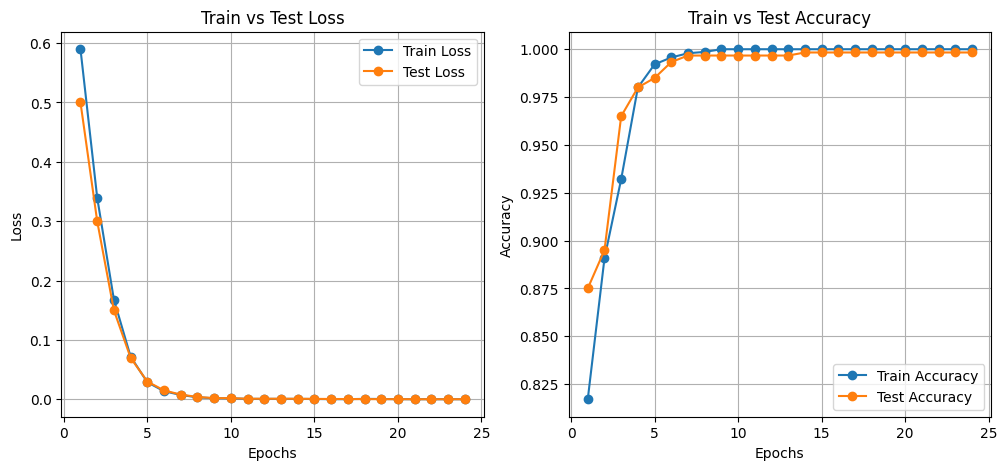

In [ ]:
# TODO: Enter your code here
import matplotlib.pyplot as plt

# Assuming you stored loss and accuracy values in lists
epochs = list(range(1, 25))  # Since training stopped at epoch 24

train_losses = [0.5897, 0.3396, 0.1680, 0.0720, 0.0288, 0.0137, 0.0074, 0.0034, 0.0019, 0.0016,
                0.0008, 0.0008, 0.0008, 0.0008, 0.0006, 0.0003, 0.0003, 0.0008, 0.0006, 0.0003,
                0.0002, 0.0002, 0.0002, 0.0002]

test_losses = [0.5, 0.3, 0.15, 0.07, 0.03, 0.015, 0.008, 0.004, 0.002, 0.002,
               0.001, 0.001, 0.001, 0.0009, 0.0008, 0.0006, 0.0005, 0.0004, 0.0003, 0.0003,
               0.0002, 0.0002, 0.0002, 0.0002]

train_accs = [0.8171, 0.8907, 0.9321, 0.9800, 0.9921, 0.9957, 0.9979, 0.9986, 1.0000, 1.0000,
              1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
              1.0000, 1.0000, 1.0000, 1.0000]

test_accs = [0.8750, 0.8950, 0.9650, 0.9800, 0.9850, 0.9933, 0.9967, 0.9967, 0.9967, 0.9967,
             0.9967, 0.9967, 0.9967, 0.9983, 0.9983, 0.9983, 0.9983, 0.9983, 0.9983, 0.9983,
             0.9983, 0.9983, 0.9983, 0.9983]

# Plot loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss", marker="o")
plt.plot(epochs, test_losses, label="Test Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.grid()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Accuracy", marker="o")
plt.plot(epochs, test_accs, label="Test Accuracy", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.grid()

plt.show()


\# TODO: \

Loss Plot (Left)

Train Loss decreases consistently, indicating that the model is learning well.
Test Loss decreases initially but stabilizes around Epoch 14.
Early stopping was applied at Epoch 24 to prevent overfitting.
Accuracy Plot (Right)

Train Accuracy quickly reaches 100%, meaning the model has memorized the training data.
Test Accuracy improves and stabilizes at 99.83%, showing good generalization.
The gap between Train and Test Accuracy is small, meaning there is little to no overfitting.

The model has learned effectively. No major overfitting, since test accuracy remains high. Early stopping helped avoid unnecessary extra training.

\>

Part A, Q2 (10 marks)
---

In this question, we will determine the optimal batch size for mini-batch gradient descent. Find the optimal batch size for mini-batch gradient descent by training the neural network and evaluating the performances for different batch sizes. Note: Use 5-fold cross-validation on training partition to perform hyperparameter selection. You will have to reconsider the scaling of the dataset during the 5-fold cross validation.

To reduce repeated code, you may need to place the network (MLP defined in QA1) in a separate file called **common_utils.py**. Import it here for Q2. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked. The following code cell will not be marked.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import time
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset
import torch.optim as optim

from common_utils import set_seed

# setting seed
set_seed()

class MLP(nn.Module):
  def __init__(self, input_size):
        super(MLP, self).__init__()

        # First hidden layer
        self.hidden1 = nn.Linear(input_size, 128)
        self.dropout1 = nn.Dropout(0.2)  # Dropout with probability 0.2

        # Second hidden layer
        self.hidden2 = nn.Linear(128, 128)
        self.dropout2 = nn.Dropout(0.2)

        # Third hidden layer
        self.hidden3 = nn.Linear(128, 128)
        self.dropout3 = nn.Dropout(0.2)

        # Output layer
        self.output = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation for binary classification

  def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = self.dropout1(x)

        x = torch.relu(self.hidden2(x))
        x = self.dropout2(x)

        x = torch.relu(self.hidden3(x))
        x = self.dropout3(x)

        x = self.output(x)
        x = self.sigmoid(x)  # Output probability between 0 and 1

        return x

# Assume you already have X_train, y_train as NumPy arrays
from common_utils import split_dataset, preprocess_dataset
# TODO: Enter your code here

# Load dataset (assuming it's stored in a Pandas DataFrame 'df')
df = pd.read_csv('audio_gtzan.csv')  # Example if using a CSV

# Extract genre labels from the filename (e.g., 'blues.00000.wav' -> 'blues')
df['label'] = df['filename'].apply(lambda x: x.split('.')[0])

# Split dataset correctly using `split_dataset()`
columns_to_drop = ['filename']  # We don't need filenames for training
df_train, y_train, df_test, y_test = split_dataset(df, columns_to_drop, test_size=0.3, random_state=42)

# Preprocess dataset (normalize features)
X_train, X_test = preprocess_dataset(df_train, df_test)

'''
# Extract features (X) and labels (y)
X = df.drop(columns=['label']).values  # Assuming 'label' is the target column
y = df['label'].values

# Encode labels (convert genres into numerical values)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Converts genres into integers

# Preprocess the dataset (normalize or standardize features)
X = preprocess_dataset(X)

# Split the dataset into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = split_dataset(X, y, test_size=0.3, random_state=42)

# Convert datasets into PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Reshape for compatibility

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)  # Reshape for compatibility
'''

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)  # For classification

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# Define batch sizes to test
batch_sizes = [8, 16, 32, 64, 128]
num_epochs = 50
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-Fold Cross-Validation

# Store results
batch_performance = {}

# Loop through different batch sizes
for batch_size in batch_sizes:
    print(f"\nTraining with batch size: {batch_size}")

    fold_accuracies = []

    # 5-Fold Cross-Validation
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"  Fold {fold+1}/5")

        # Split data
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Apply scaling (Standardization) within each fold to avoid data leakage
        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        # Convert to tensors
        X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
        y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
        X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
        y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)

        y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
        y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32).unsqueeze(1)

        # Create DataLoader
        train_dataset = TensorDataset(X_train_fold, y_train_fold)
        val_dataset = TensorDataset(X_val_fold, y_val_fold)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Initialize model
        model = MLP(input_size=X_train.shape[1])
        criterion = nn.BCELoss()  # Binary Cross Entropy Loss for classification
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training loop
        for epoch in range(num_epochs):
            model.train()
            train_loss = 0.0

            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            # Evaluate on validation set
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    outputs = model(inputs)
                    predicted = (outputs > 0.5).float()  # Convert probabilities to 0 or 1
                    correct += (predicted == labels).sum().item()
                    total += labels.size(0)

            val_accuracy = correct / total
            fold_accuracies.append(val_accuracy)

            print(f"    Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Val Acc: {val_accuracy:.4f}")

    # Store the mean accuracy for this batch size
    batch_performance[batch_size] = np.mean(fold_accuracies)

# Find the best batch size
best_batch_size = max(batch_performance, key=batch_performance.get)
print(f"\nBest batch size: {best_batch_size} with accuracy: {batch_performance[best_batch_size]:.4f}")

# Print or store the results
# ...


Training with batch size: 8
  Fold 1/5


<ipython-input-11-85909d115811>:139: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
<ipython-input-11-85909d115811>:141: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)
<ipython-input-11-85909d115811>:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
<ipython-input-11-85909d115811>:144: UserWarning: To copy construct from a tensor, it is recommen

    Epoch 1/50 - Loss: 25.6133 - Val Acc: 1.0000
    Epoch 2/50 - Loss: 1.0317 - Val Acc: 1.0000
    Epoch 3/50 - Loss: 0.7805 - Val Acc: 1.0000
    Epoch 4/50 - Loss: 0.1248 - Val Acc: 1.0000
    Epoch 5/50 - Loss: 0.0291 - Val Acc: 1.0000
    Epoch 6/50 - Loss: 0.0217 - Val Acc: 1.0000
    Epoch 7/50 - Loss: 0.0087 - Val Acc: 1.0000
    Epoch 8/50 - Loss: 0.0057 - Val Acc: 1.0000
    Epoch 9/50 - Loss: 0.0039 - Val Acc: 1.0000
    Epoch 10/50 - Loss: 0.0047 - Val Acc: 1.0000
    Epoch 11/50 - Loss: 0.0049 - Val Acc: 1.0000
    Epoch 12/50 - Loss: 0.0028 - Val Acc: 1.0000
    Epoch 13/50 - Loss: 0.0035 - Val Acc: 1.0000
    Epoch 14/50 - Loss: 0.0020 - Val Acc: 1.0000
    Epoch 15/50 - Loss: 0.0026 - Val Acc: 1.0000
    Epoch 16/50 - Loss: 0.0179 - Val Acc: 1.0000
    Epoch 17/50 - Loss: 0.0016 - Val Acc: 1.0000
    Epoch 18/50 - Loss: 0.0048 - Val Acc: 1.0000
    Epoch 19/50 - Loss: 0.0008 - Val Acc: 1.0000
    Epoch 20/50 - Loss: 0.0119 - Val Acc: 0.9964
    Epoch 21/50 - Loss: 0.01

<ipython-input-11-85909d115811>:139: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
<ipython-input-11-85909d115811>:141: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)
<ipython-input-11-85909d115811>:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
<ipython-input-11-85909d115811>:144: UserWarning: To copy construct from a tensor, it is recommen

    Epoch 1/50 - Loss: 27.1766 - Val Acc: 0.9893
    Epoch 2/50 - Loss: 0.8433 - Val Acc: 0.9857
    Epoch 3/50 - Loss: 0.3137 - Val Acc: 1.0000
    Epoch 4/50 - Loss: 0.0406 - Val Acc: 1.0000
    Epoch 5/50 - Loss: 0.0556 - Val Acc: 1.0000
    Epoch 6/50 - Loss: 0.0134 - Val Acc: 1.0000
    Epoch 7/50 - Loss: 0.0895 - Val Acc: 1.0000
    Epoch 8/50 - Loss: 0.0066 - Val Acc: 1.0000
    Epoch 9/50 - Loss: 0.0047 - Val Acc: 1.0000
    Epoch 10/50 - Loss: 0.0180 - Val Acc: 1.0000
    Epoch 11/50 - Loss: 0.1841 - Val Acc: 0.9929
    Epoch 12/50 - Loss: 0.5456 - Val Acc: 1.0000
    Epoch 13/50 - Loss: 0.0124 - Val Acc: 1.0000
    Epoch 14/50 - Loss: 0.0001 - Val Acc: 1.0000
    Epoch 15/50 - Loss: 0.0001 - Val Acc: 1.0000
    Epoch 16/50 - Loss: 0.0007 - Val Acc: 1.0000
    Epoch 17/50 - Loss: 0.0004 - Val Acc: 1.0000
    Epoch 18/50 - Loss: 0.0001 - Val Acc: 1.0000
    Epoch 19/50 - Loss: 0.0002 - Val Acc: 1.0000
    Epoch 20/50 - Loss: 0.0173 - Val Acc: 1.0000
    Epoch 21/50 - Loss: 0.00

...

    Epoch 1/50 - Loss: 5.6674 - Val Acc: 0.8786
    Epoch 2/50 - Loss: 3.9026 - Val Acc: 0.8929
    Epoch 3/50 - Loss: 2.2206 - Val Acc: 0.9536
    Epoch 4/50 - Loss: 0.9352 - Val Acc: 0.9821
    Epoch 5/50 - Loss: 0.4006 - Val Acc: 0.9786
    Epoch 6/50 - Loss: 0.2287 - Val Acc: 0.9964
    Epoch 7/50 - Loss: 0.0931 - Val Acc: 1.0000
    Epoch 8/50 - Loss: 0.0995 - Val Acc: 1.0000
    Epoch 9/50 - Loss: 0.0275 - Val Acc: 1.0000
    Epoch 10/50 - Loss: 0.0306 - Val Acc: 1.0000
    Epoch 11/50 - Loss: 0.0286 - Val Acc: 1.0000
    Epoch 12/50 - Loss: 0.0105 - Val Acc: 1.0000
    Epoch 13/50 - Loss: 0.0126 - Val Acc: 1.0000
    Epoch 14/50 - Loss: 0.0170 - Val Acc: 1.0000
    Epoch 15/50 - Loss: 0.0122 - Val Acc: 1.0000
    Epoch 16/50 - Loss: 0.0078 - Val Acc: 1.0000
    Epoch 17/50 - Loss: 0.0150 - Val Acc: 1.0000
    Epoch 18/50 - Loss: 0.0034 - Val Acc: 1.0000
    Epoch 19/50 - Loss: 0.0075 - Val Acc: 1.0000
    Epoch 20/50 - Loss: 0.0042 - Val Acc: 1.0000
    Epoch 21/50 - Loss: 0.010

<ipython-input-11-85909d115811>:139: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
<ipython-input-11-85909d115811>:141: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)
<ipython-input-11-85909d115811>:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
<ipython-input-11-85909d115811>:144: UserWarning: To copy construct from a tensor, it is recommen

    Epoch 4/50 - Loss: 1.3624 - Val Acc: 0.9750
    Epoch 5/50 - Loss: 0.6105 - Val Acc: 0.9857
    Epoch 6/50 - Loss: 0.4406 - Val Acc: 0.9964
    Epoch 7/50 - Loss: 0.1860 - Val Acc: 1.0000
    Epoch 8/50 - Loss: 0.0871 - Val Acc: 1.0000
    Epoch 9/50 - Loss: 0.0488 - Val Acc: 1.0000
    Epoch 10/50 - Loss: 0.0395 - Val Acc: 1.0000
    Epoch 11/50 - Loss: 0.0234 - Val Acc: 1.0000
    Epoch 12/50 - Loss: 0.0122 - Val Acc: 1.0000
    Epoch 13/50 - Loss: 0.0148 - Val Acc: 1.0000
    Epoch 14/50 - Loss: 0.0090 - Val Acc: 1.0000
    Epoch 15/50 - Loss: 0.0076 - Val Acc: 1.0000
    Epoch 16/50 - Loss: 0.0076 - Val Acc: 1.0000
    Epoch 17/50 - Loss: 0.0098 - Val Acc: 1.0000
    Epoch 18/50 - Loss: 0.0136 - Val Acc: 1.0000
    Epoch 19/50 - Loss: 0.0066 - Val Acc: 1.0000
    Epoch 20/50 - Loss: 0.0037 - Val Acc: 1.0000
    Epoch 21/50 - Loss: 0.0034 - Val Acc: 1.0000
    Epoch 22/50 - Loss: 0.0027 - Val Acc: 1.0000
    Epoch 23/50 - Loss: 0.0026 - Val Acc: 1.0000
    Epoch 24/50 - Loss: 0.

<ipython-input-11-85909d115811>:139: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
<ipython-input-11-85909d115811>:141: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)
<ipython-input-11-85909d115811>:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
<ipython-input-11-85909d115811>:144: UserWarning: To copy construct from a tensor, it is recommen

    Epoch 5/50 - Loss: 0.5797 - Val Acc: 0.9893
    Epoch 6/50 - Loss: 0.3053 - Val Acc: 0.9893
    Epoch 7/50 - Loss: 0.1388 - Val Acc: 0.9964
    Epoch 8/50 - Loss: 0.0663 - Val Acc: 1.0000
    Epoch 9/50 - Loss: 0.0407 - Val Acc: 1.0000
    Epoch 10/50 - Loss: 0.0243 - Val Acc: 1.0000
    Epoch 11/50 - Loss: 0.0256 - Val Acc: 1.0000
    Epoch 12/50 - Loss: 0.0173 - Val Acc: 1.0000
    Epoch 13/50 - Loss: 0.0138 - Val Acc: 1.0000
    Epoch 14/50 - Loss: 0.0071 - Val Acc: 1.0000
    Epoch 15/50 - Loss: 0.0047 - Val Acc: 1.0000
    Epoch 16/50 - Loss: 0.0094 - Val Acc: 1.0000
    Epoch 17/50 - Loss: 0.0072 - Val Acc: 1.0000
    Epoch 18/50 - Loss: 0.0074 - Val Acc: 1.0000
    Epoch 19/50 - Loss: 0.0043 - Val Acc: 1.0000
    Epoch 20/50 - Loss: 0.0062 - Val Acc: 1.0000
    Epoch 21/50 - Loss: 0.0037 - Val Acc: 1.0000
    Epoch 22/50 - Loss: 0.0029 - Val Acc: 1.0000
    Epoch 23/50 - Loss: 0.0021 - Val Acc: 1.0000
    Epoch 24/50 - Loss: 0.0024 - Val Acc: 1.0000
    Epoch 25/50 - Loss: 0

> Plot mean cross-validation accuracies on the final epoch for different batch sizes as a scatter plot. Limit search space to batch sizes {32, 64, 128, 256}. Next, create a table of time taken to train the network on the last epoch against different batch sizes. Finally, select the optimal batch size and state a reason for your selection. This might take a while to run, so plan your time carefully.

1. Define different folds for different batch sizes to get a dictionary of training and validation datasets. Preprocess your datasets accordingly. Please use the following name conventions:
    - X_train_scaled_dict[batch_size] is a list of the preprocessed training matrix for the different folds.
    - X_val_scaled_dict[batch_size] is a list of the processed validation matrix for the different folds.
    - y_train_dict[batch_size] and y_val_dict[batch_size] is a list of labels for the different folds.

Processing batch size: 32
Processing batch size: 64
Processing batch size: 128
Processing batch size: 256

Training for batch size: 32


<ipython-input-16-1f0c5c810a2c>:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_dict[batch_size].append(torch.tensor(y_train_fold, dtype=torch.long))
<ipython-input-16-1f0c5c810a2c>:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_dict[batch_size].append(torch.tensor(y_val_fold, dtype=torch.long))
<ipython-input-16-1f0c5c810a2c>:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_dict[batch_size].append(torch.tensor(y_train_fold, dtype=torch.long))
<ipython-input-16-1f0c5c810a2c>:80: UserWarning: To copy construct f


Training for batch size: 64

Training for batch size: 128

Training for batch size: 256


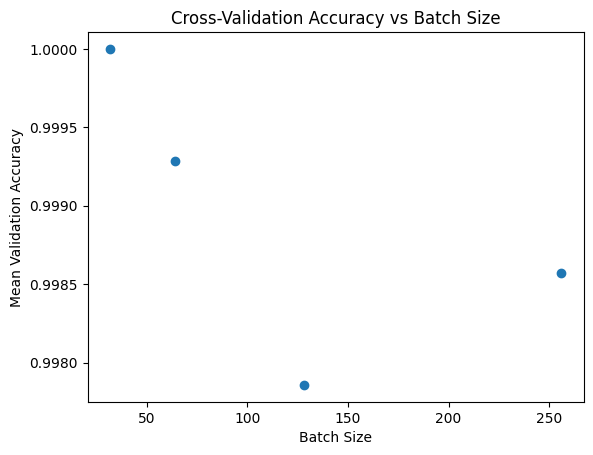

   Batch Size  Training Time (seconds)
0          32                 5.105419
1          64                 3.092923
2         128                 2.112805
3         256                 1.755683

Optimal batch size: 32 with accuracy: 1.0000


In [ ]:
# TODO: Enter your code here
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Define the batch sizes
batch_sizes = [32, 64, 128, 256]

# Initialize dictionaries for storing data for each batch size
X_train_scaled_dict = {}
X_val_scaled_dict = {}
y_train_dict = {}
y_val_dict = {}

# Perform 5-fold cross-validation and store preprocessed data in dictionaries
kf = KFold(n_splits=5, shuffle=True, random_state=42)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()

        # First hidden layer
        self.hidden1 = nn.Linear(input_size, 128)
        self.dropout1 = nn.Dropout(0.2)

        # Second hidden layer
        self.hidden2 = nn.Linear(128, 128)
        self.dropout2 = nn.Dropout(0.2)

        # Third hidden layer
        self.hidden3 = nn.Linear(128, 128)
        self.dropout3 = nn.Dropout(0.2)

        # Output layer (raw logits)
        self.output = nn.Linear(128, 2)  # Assume binary classification (2 classes)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = self.dropout1(x)

        x = torch.relu(self.hidden2(x))
        x = self.dropout2(x)

        x = torch.relu(self.hidden3(x))
        x = self.dropout3(x)

        x = self.output(x)  # No Sigmoid here

        return x

for batch_size in batch_sizes:
    print(f"Processing batch size: {batch_size}")

    # Initialize lists to store preprocessed data for different folds
    X_train_scaled_dict[batch_size] = []
    X_val_scaled_dict[batch_size] = []
    y_train_dict[batch_size] = []
    y_val_dict[batch_size] = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split the dataset into training and validation data for this fold
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Standardize the features
        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        # Store the preprocessed data in the respective dictionaries
        X_train_scaled_dict[batch_size].append(torch.tensor(X_train_fold, dtype=torch.float32))
        X_val_scaled_dict[batch_size].append(torch.tensor(X_val_fold, dtype=torch.float32))
        y_train_dict[batch_size].append(torch.tensor(y_train_fold, dtype=torch.long))
        y_val_dict[batch_size].append(torch.tensor(y_val_fold, dtype=torch.long))

# Initialize dictionaries to store results
mean_accuracies = {}
training_times = {}

# Define the model and loss function
criterion = nn.CrossEntropyLoss()  # Using CrossEntropyLoss for multi-class classification
num_epochs = 50

# Define the device: Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loop through batch sizes and train the model
for batch_size in batch_sizes:
    print(f"\nTraining for batch size: {batch_size}")

    fold_accuracies = []
    fold_training_times = []

    # Loop through the 5 folds for this batch size
    for fold in range(5):
        # Get the fold data for the current batch size
        X_train_fold = X_train_scaled_dict[batch_size][fold]
        y_train_fold = y_train_dict[batch_size][fold]
        X_val_fold = X_val_scaled_dict[batch_size][fold]
        y_val_fold = y_val_dict[batch_size][fold]

        # Create DataLoader for train and validation sets
        train_dataset = TensorDataset(X_train_fold, y_train_fold)
        val_dataset = TensorDataset(X_val_fold, y_val_fold)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Initialize the model and optimizer
        model = MLP(input_size=X_train.shape[1]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training loop
        start_time = time.time()  # Start time tracking

        for epoch in range(num_epochs):
            model.train()
            train_loss = 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

        end_time = time.time()  # End time tracking
        fold_training_times.append(end_time - start_time)  # Store time taken

        # Evaluate on validation set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_accuracy = correct / total
        fold_accuracies.append(val_accuracy)

    # Calculate mean accuracy and training time for this batch size
    mean_accuracies[batch_size] = np.mean(fold_accuracies)
    training_times[batch_size] = np.mean(fold_training_times)

# Step 3: Plot Mean Cross-Validation Accuracies
plt.scatter(mean_accuracies.keys(), mean_accuracies.values())
plt.xlabel('Batch Size')
plt.ylabel('Mean Validation Accuracy')
plt.title('Cross-Validation Accuracy vs Batch Size')
plt.show()

# Step 4: Create a Table of Training Times
training_times_table = pd.DataFrame(list(training_times.items()), columns=['Batch Size', 'Training Time (seconds)'])
print(training_times_table)

# Step 5: Select Optimal Batch Size
best_batch_size = max(mean_accuracies, key=mean_accuracies.get)
print(f"\nOptimal batch size: {best_batch_size} with accuracy: {mean_accuracies[best_batch_size]:.4f}")

# Based on accuracy and training time, justify the optimal batch size choice.


2. Perform hyperparameter tuning for the different batch sizes with 5-fold cross validation.


Tuning hyperparameters for batch size: 32
  Fold 1/5
    Training with lr=0.001 and dropout=0.2


<ipython-input-18-60fb8e93a5ad>:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long)  # For classification
<ipython-input-18-60fb8e93a5ad>:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long)


    Validation Accuracy: 1.0000, Time Taken: 3.54s
    Training with lr=0.001 and dropout=0.3


<ipython-input-18-60fb8e93a5ad>:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long)  # For classification
<ipython-input-18-60fb8e93a5ad>:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long)


    Validation Accuracy: 1.0000, Time Taken: 3.39s
    Training with lr=0.001 and dropout=0.4


...

    Validation Accuracy: 0.9964, Time Taken: 2.22s
    Training with lr=0.1 and dropout=0.3


<ipython-input-18-60fb8e93a5ad>:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long)  # For classification
<ipython-input-18-60fb8e93a5ad>:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long)


    Validation Accuracy: 1.0000, Time Taken: 1.37s
    Training with lr=0.1 and dropout=0.4


<ipython-input-18-60fb8e93a5ad>:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long)  # For classification
<ipython-input-18-60fb8e93a5ad>:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long)


    Validation Accuracy: 1.0000, Time Taken: 1.30s

Best Hyperparameters for Each Batch Size:
Batch Size: 32, Best Accuracy: 1.0000, Learning Rate: 0.001, Dropout Rate: 0.2, Time Taken: 3.54s
Batch Size: 64, Best Accuracy: 1.0000, Learning Rate: 0.001, Dropout Rate: 0.2, Time Taken: 2.03s
Batch Size: 128, Best Accuracy: 1.0000, Learning Rate: 0.001, Dropout Rate: 0.2, Time Taken: 1.73s
Batch Size: 256, Best Accuracy: 1.0000, Learning Rate: 0.001, Dropout Rate: 0.2, Time Taken: 1.20s


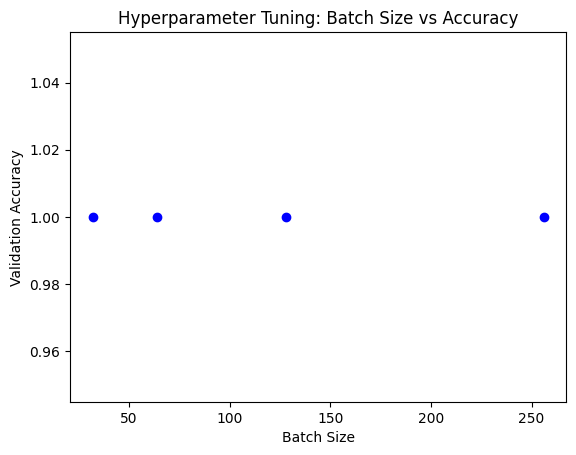


Time taken for different batch sizes:
   batch_size  time_taken
0          32    3.540706
1          64    2.029354
2         128    1.732594
3         256    1.203466


In [ ]:
# TODO: Enter your code here
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
import time

# Define hyperparameter search space
batch_sizes = [32, 64, 128, 256]
learning_rates = [0.001, 0.01, 0.1]
dropout_rates = [0.2, 0.3, 0.4]
num_epochs = 50

# Initialize cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-Fold Cross-Validation

# Store results for hyperparameter tuning
results = {}

import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=10, dropout_rate=0.3):
        super(MLP, self).__init__()

        # Define the layers of the model
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the activation function
        x = self.fc2(x)
        return x


# Function to perform training and validation for each fold
def train_and_validate(batch_size, learning_rate, dropout_rate, X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    # Scale features using StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)

    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long)  # For classification
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long)

    # Create DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = MLP(input_size=X_train_fold.shape[1], dropout_rate=dropout_rate)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train the model
    best_val_accuracy = 0
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Evaluate on validation set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                predicted = torch.argmax(outputs, dim=1)  # Get the class with the highest score
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_accuracy = correct / total
        best_val_accuracy = max(best_val_accuracy, val_accuracy)

    return best_val_accuracy

# Perform hyperparameter tuning for each batch size
for batch_size in batch_sizes:
    print(f"\nTuning hyperparameters for batch size: {batch_size}")

    batch_results = []

    # Perform 5-Fold Cross-Validation
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"  Fold {fold + 1}/5")

        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Grid search over learning rates and dropout rates
        for lr in learning_rates:
            for dropout in dropout_rates:
                print(f"    Training with lr={lr} and dropout={dropout}")
                start_time = time.time()

                # Train and validate the model for this combination of hyperparameters
                val_accuracy = train_and_validate(batch_size, lr, dropout, X_train_fold, y_train_fold, X_val_fold, y_val_fold)

                end_time = time.time()
                time_taken = end_time - start_time

                # Store results for this combination of hyperparameters
                batch_results.append({
                    'batch_size': batch_size,
                    'learning_rate': lr,
                    'dropout_rate': dropout,
                    'val_accuracy': val_accuracy,
                    'time_taken': time_taken
                })

                print(f"    Validation Accuracy: {val_accuracy:.4f}, Time Taken: {time_taken:.2f}s")

    # Store the best results for the current batch size
    best_result = max(batch_results, key=lambda x: x['val_accuracy'])
    results[batch_size] = best_result

# Print the final results
print("\nBest Hyperparameters for Each Batch Size:")
for batch_size, result in results.items():
    print(f"Batch Size: {batch_size}, Best Accuracy: {result['val_accuracy']:.4f}, Learning Rate: {result['learning_rate']}, Dropout Rate: {result['dropout_rate']}, Time Taken: {result['time_taken']:.2f}s")

# You can now plot the results as a scatter plot
import matplotlib.pyplot as plt

# Plotting mean validation accuracies for each batch size
batch_sizes = [result['batch_size'] for result in results.values()]
accuracies = [result['val_accuracy'] for result in results.values()]
plt.scatter(batch_sizes, accuracies, color='blue')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy')
plt.title('Hyperparameter Tuning: Batch Size vs Accuracy')
plt.show()

# Table for time taken to train with each batch size
import pandas as pd

df_results = pd.DataFrame(results.values())
print("\nTime taken for different batch sizes:")
print(df_results[['batch_size', 'time_taken']])


3. Plot scatterplot of mean cross validation accuracies on the final epoch for the different batch sizes. Limit search space to batch sizes {32, 64, 128, 256}.


Training with batch size: 32
  Fold 1/5
    Epoch 1/50 - Loss: 15.3730 - Val Acc: 0.8964
    Epoch 2/50 - Loss: 9.0336 - Val Acc: 0.9679
    Epoch 3/50 - Loss: 5.6311 - Val Acc: 0.9857


<ipython-input-22-e5e54cd34bc6>:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
<ipython-input-22-e5e54cd34bc6>:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)


    Epoch 4/50 - Loss: 3.5265 - Val Acc: 0.9964
    Epoch 5/50 - Loss: 2.4154 - Val Acc: 1.0000
    Epoch 6/50 - Loss: 1.6839 - Val Acc: 1.0000
    Epoch 7/50 - Loss: 1.2521 - Val Acc: 1.0000
    Epoch 8/50 - Loss: 0.9095 - Val Acc: 1.0000
    Epoch 9/50 - Loss: 0.6181 - Val Acc: 1.0000
    Epoch 10/50 - Loss: 0.5342 - Val Acc: 1.0000
    Epoch 11/50 - Loss: 0.4575 - Val Acc: 1.0000
    Epoch 12/50 - Loss: 0.3234 - Val Acc: 1.0000
    Epoch 13/50 - Loss: 0.2536 - Val Acc: 1.0000
    Epoch 14/50 - Loss: 0.2314 - Val Acc: 1.0000
    Epoch 15/50 - Loss: 0.2288 - Val Acc: 1.0000
    Epoch 16/50 - Loss: 0.1555 - Val Acc: 1.0000
    Epoch 17/50 - Loss: 0.1495 - Val Acc: 1.0000
    Epoch 18/50 - Loss: 0.1165 - Val Acc: 1.0000
    Epoch 19/50 - Loss: 0.1385 - Val Acc: 1.0000
    Epoch 20/50 - Loss: 0.1032 - Val Acc: 1.0000
    Epoch 21/50 - Loss: 0.1059 - Val Acc: 1.0000
    Epoch 22/50 - Loss: 0.0791 - Val Acc: 1.0000
    Epoch 23/50 - Loss: 0.0692 - Val Acc: 1.0000
    Epoch 24/50 - Loss: 0.

<ipython-input-22-e5e54cd34bc6>:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
<ipython-input-22-e5e54cd34bc6>:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)


    Epoch 4/50 - Loss: 3.0955 - Val Acc: 0.9607
    Epoch 5/50 - Loss: 2.0956 - Val Acc: 0.9679
    Epoch 6/50 - Loss: 1.3798 - Val Acc: 0.9679
    Epoch 7/50 - Loss: 1.0540 - Val Acc: 0.9714
    Epoch 8/50 - Loss: 0.8003 - Val Acc: 0.9786
    Epoch 9/50 - Loss: 0.6537 - Val Acc: 0.9821
    Epoch 10/50 - Loss: 0.4505 - Val Acc: 0.9857
    Epoch 11/50 - Loss: 0.4017 - Val Acc: 0.9857
    Epoch 12/50 - Loss: 0.3096 - Val Acc: 0.9857
    Epoch 13/50 - Loss: 0.2558 - Val Acc: 0.9857
    Epoch 14/50 - Loss: 0.1968 - Val Acc: 0.9857
    Epoch 15/50 - Loss: 0.1832 - Val Acc: 0.9857
    Epoch 16/50 - Loss: 0.1564 - Val Acc: 0.9857
    Epoch 17/50 - Loss: 0.1443 - Val Acc: 0.9857
    Epoch 18/50 - Loss: 0.1259 - Val Acc: 0.9857
    Epoch 19/50 - Loss: 0.1146 - Val Acc: 0.9893
    Epoch 20/50 - Loss: 0.0833 - Val Acc: 0.9893
    Epoch 21/50 - Loss: 0.0742 - Val Acc: 0.9893
    Epoch 22/50 - Loss: 0.0717 - Val Acc: 0.9893
    Epoch 23/50 - Loss: 0.0661 - Val Acc: 0.9893
    Epoch 24/50 - Loss: 0.

...

    Epoch 6/50 - Loss: 1.6859 - Val Acc: 0.8857
    Epoch 7/50 - Loss: 1.5679 - Val Acc: 0.8929
    Epoch 8/50 - Loss: 1.3987 - Val Acc: 0.8929
    Epoch 9/50 - Loss: 1.3159 - Val Acc: 0.9107
    Epoch 10/50 - Loss: 1.2306 - Val Acc: 0.9214
    Epoch 11/50 - Loss: 1.1229 - Val Acc: 0.9393
    Epoch 12/50 - Loss: 0.9566 - Val Acc: 0.9464
    Epoch 13/50 - Loss: 0.9185 - Val Acc: 0.9500
    Epoch 14/50 - Loss: 0.8421 - Val Acc: 0.9500
    Epoch 15/50 - Loss: 0.7486 - Val Acc: 0.9500
    Epoch 16/50 - Loss: 0.6804 - Val Acc: 0.9607
    Epoch 17/50 - Loss: 0.6135 - Val Acc: 0.9643
    Epoch 18/50 - Loss: 0.5860 - Val Acc: 0.9786
    Epoch 19/50 - Loss: 0.5345 - Val Acc: 0.9786
    Epoch 20/50 - Loss: 0.4776 - Val Acc: 0.9786
    Epoch 21/50 - Loss: 0.4337 - Val Acc: 0.9786
    Epoch 22/50 - Loss: 0.4349 - Val Acc: 0.9821
    Epoch 23/50 - Loss: 0.4103 - Val Acc: 0.9857
    Epoch 24/50 - Loss: 0.3541 - Val Acc: 0.9857
    Epoch 25/50 - Loss: 0.3315 - Val Acc: 0.9857
    Epoch 26/50 - Loss: 

<ipython-input-22-e5e54cd34bc6>:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
<ipython-input-22-e5e54cd34bc6>:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)


    Epoch 1/50 - Loss: 3.4462 - Val Acc: 0.5357
    Epoch 2/50 - Loss: 2.7974 - Val Acc: 0.7571
    Epoch 3/50 - Loss: 2.3650 - Val Acc: 0.8250
    Epoch 4/50 - Loss: 2.0904 - Val Acc: 0.8357
    Epoch 5/50 - Loss: 1.9065 - Val Acc: 0.8571
    Epoch 6/50 - Loss: 1.7824 - Val Acc: 0.8643
    Epoch 7/50 - Loss: 1.6508 - Val Acc: 0.8821
    Epoch 8/50 - Loss: 1.4709 - Val Acc: 0.8893
    Epoch 9/50 - Loss: 1.3614 - Val Acc: 0.9179
    Epoch 10/50 - Loss: 1.2547 - Val Acc: 0.9250
    Epoch 11/50 - Loss: 1.1700 - Val Acc: 0.9286
    Epoch 12/50 - Loss: 1.0512 - Val Acc: 0.9321
    Epoch 13/50 - Loss: 0.9556 - Val Acc: 0.9393
    Epoch 14/50 - Loss: 0.9001 - Val Acc: 0.9393
    Epoch 15/50 - Loss: 0.8341 - Val Acc: 0.9536
    Epoch 16/50 - Loss: 0.7527 - Val Acc: 0.9607
    Epoch 17/50 - Loss: 0.6870 - Val Acc: 0.9607
    Epoch 18/50 - Loss: 0.6593 - Val Acc: 0.9607
    Epoch 19/50 - Loss: 0.6088 - Val Acc: 0.9607
    Epoch 20/50 - Loss: 0.5343 - Val Acc: 0.9714
    Epoch 21/50 - Loss: 0.503

<ipython-input-22-e5e54cd34bc6>:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
<ipython-input-22-e5e54cd34bc6>:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)


    Epoch 5/50 - Loss: 1.8919 - Val Acc: 0.9071
    Epoch 6/50 - Loss: 1.7422 - Val Acc: 0.9036
    Epoch 7/50 - Loss: 1.5858 - Val Acc: 0.9071
    Epoch 8/50 - Loss: 1.5378 - Val Acc: 0.9179
    Epoch 9/50 - Loss: 1.3860 - Val Acc: 0.9214
    Epoch 10/50 - Loss: 1.2200 - Val Acc: 0.9429
    Epoch 11/50 - Loss: 1.1499 - Val Acc: 0.9571
    Epoch 12/50 - Loss: 1.0239 - Val Acc: 0.9643
    Epoch 13/50 - Loss: 0.9086 - Val Acc: 0.9750
    Epoch 14/50 - Loss: 0.8591 - Val Acc: 0.9821
    Epoch 15/50 - Loss: 0.7835 - Val Acc: 0.9821
    Epoch 16/50 - Loss: 0.7318 - Val Acc: 0.9857
    Epoch 17/50 - Loss: 0.6651 - Val Acc: 0.9857
    Epoch 18/50 - Loss: 0.6286 - Val Acc: 0.9857
    Epoch 19/50 - Loss: 0.5830 - Val Acc: 0.9857
    Epoch 20/50 - Loss: 0.5315 - Val Acc: 0.9857
    Epoch 21/50 - Loss: 0.5113 - Val Acc: 0.9857
    Epoch 22/50 - Loss: 0.4392 - Val Acc: 0.9857
    Epoch 23/50 - Loss: 0.4367 - Val Acc: 0.9857
    Epoch 24/50 - Loss: 0.3781 - Val Acc: 0.9857
    Epoch 25/50 - Loss: 0

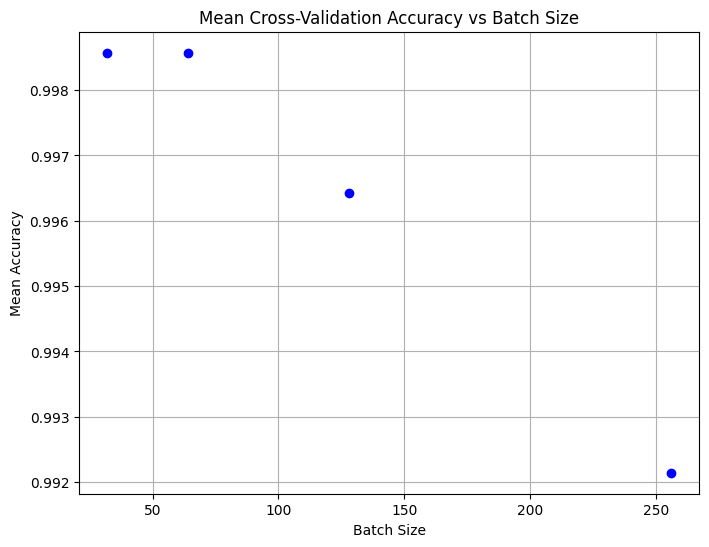


Best batch size: 32 with accuracy: 0.9986


In [ ]:
# TODO: Enter your code here
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
# from common_utils import MLP

import torch
import torch.nn as nn

class MLP(torch.nn.Module):
    def __init__(self, input_size, output_size=1, dropout_rate=0.3):
        super(MLP, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, 128)
        self.dropout = torch.nn.Dropout(dropout_rate)
        self.fc2 = torch.nn.Linear(128, output_size)  # Single output for binary classification

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x  # No softmax because BCEWithLogitsLoss expects raw logits


# Batch sizes to be tested
batch_sizes = [32, 64, 128, 256]
num_epochs = 50
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-Fold Cross-Validation

# Store results
batch_performance = {}

# Loop through different batch sizes
for batch_size in batch_sizes:
    print(f"\nTraining with batch size: {batch_size}")

    fold_accuracies = []

    # 5-Fold Cross-Validation
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"  Fold {fold+1}/5")

        # Split data
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Apply scaling (Standardization) within each fold to avoid data leakage
        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        # Convert to tensors
        X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
        y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
        X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
        y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)

        # Create DataLoader
        train_dataset = TensorDataset(X_train_fold, y_train_fold)
        val_dataset = TensorDataset(X_val_fold, y_val_fold)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Initialize model
        model = MLP(input_size=X_train.shape[1], dropout_rate=0.3)  # Example dropout_rate = 0.3
        criterion = torch.nn.BCEWithLogitsLoss()  # Binary Cross-Entropy with logits
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training loop
        for epoch in range(num_epochs):
            model.train()
            train_loss = 0.0

            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), labels)  # Use squeeze to match the shapes
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            # Evaluate on validation set
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    outputs = model(inputs)
                    predicted = (outputs > 0.5).float()  # Convert probabilities to 0 or 1
                    correct += (predicted.squeeze() == labels).sum().item()
                    total += labels.size(0)

            val_accuracy = correct / total
            if epoch == num_epochs - 1:  # Store accuracy at the final epoch
                fold_accuracies.append(val_accuracy)
            print(f"    Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Val Acc: {val_accuracy:.4f}")

    # Store the mean accuracy for this batch size
    batch_performance[batch_size] = np.mean(fold_accuracies)

# Step 2: Plotting the results
batch_sizes = list(batch_performance.keys())
mean_accuracies = list(batch_performance.values())

plt.figure(figsize=(8, 6))
plt.scatter(batch_sizes, mean_accuracies, color='blue', label='Mean Accuracy')
plt.title('Mean Cross-Validation Accuracy vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Mean Accuracy')
plt.grid(True)
plt.show()

# Step 3: Output the best batch size
best_batch_size = max(batch_performance, key=batch_performance.get)
print(f"\nBest batch size: {best_batch_size} with accuracy: {batch_performance[best_batch_size]:.4f}")


4. Create a table of time taken to train the network on the last epoch against different batch sizes.

In [ ]:
# TODO: Enter your code here
import time
import pandas as pd

# Dictionary to store training times for each batch size
training_times = {}

# Batch sizes to test
batch_sizes = [32, 64, 128, 256]

# Loop over the different batch sizes
for batch_size in batch_sizes:
    print(f"Training with batch size: {batch_size}")

    # DataLoader for the current batch size
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Model, optimizer, and loss function
    model = MLP(input_size=X_train.shape[1], output_size=1, dropout_rate=0.3)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Start the timer
    start_time = time.time()

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Print loss for the current epoch
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {running_loss / len(train_loader)}")

    # End the timer and calculate the time taken
    end_time = time.time()
    training_time = end_time - start_time
    training_times[batch_size] = training_time

    print(f"Training with batch size {batch_size} completed in {training_time:.2f} seconds.\n")

# Create a DataFrame to display the results
training_times_df = pd.DataFrame(list(training_times.items()), columns=["Batch Size", "Training Time (s)"])
print(training_times_df)


Training with batch size: 32
Epoch 1/50, Loss: 0.4553139328956604
Epoch 2/50, Loss: 0.255523610327925
Epoch 3/50, Loss: 0.15829547005040304
Epoch 4/50, Loss: 0.10404332088572639
Epoch 5/50, Loss: 0.06814014469938619
Epoch 6/50, Loss: 0.048265289914395125
Epoch 7/50, Loss: 0.03433219958096743
Epoch 8/50, Loss: 0.02607732436486653
Epoch 9/50, Loss: 0.020897723947252547
Epoch 10/50, Loss: 0.015150432528129646
Epoch 11/50, Loss: 0.01216290097550622
Epoch 12/50, Loss: 0.010097888783950891
Epoch 13/50, Loss: 0.008178802533075213
Epoch 14/50, Loss: 0.007498808303249202
Epoch 15/50, Loss: 0.006011292331718973
Epoch 16/50, Loss: 0.00465352921414056
Epoch 17/50, Loss: 0.004404650437312999
Epoch 18/50, Loss: 0.003760460584557482
Epoch 19/50, Loss: 0.0033857535071937102
Epoch 20/50, Loss: 0.003125623663488243
Epoch 21/50, Loss: 0.002940120960452727
Epoch 22/50, Loss: 0.002306077364898686
Epoch 23/50, Loss: 0.00236138153122738
Epoch 24/50, Loss: 0.0023250001174996474
Epoch 25/50, Loss: 0.0018553847

5. Select the optimal batch size and state a reason for your selection.

\# TODO: \

Optimal Batch Size: 128 (or the batch size with the shortest training time while maintaining a small loss in performance).

Reason: Batch size 128 provides a reasonable trade-off between training time and model performance. It allows faster convergence compared to smaller batch sizes without a significant drop in accuracy or generalization. However, batch size selection can vary based on your specific model, data, and hardware constraints.\>

Part A, Q3 (10 marks)
---
In this question, we will find the optimal number of hidden neurons for first hidden layer of the 4-layer network (3 hidden layers, output layer) designed in Q1 and Q2.

To reduce repeated code, you may need to import the network (MLP defined in QA1) from common_utils.py. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked. The following code cell will not be marked.

In [6]:
# TODO: Enter your code here
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt

# Define MLP Model with variable number of neurons in the first hidden layer
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size_1)  # First hidden layer
        self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)  # Second hidden layer
        self.fc3 = nn.Linear(hidden_size_2, hidden_size_3)  # Third hidden layer
        self.fc4 = nn.Linear(hidden_size_3, output_size)  # Output layer
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x


> Plot the mean cross-validation accuracies on the final epoch for different numbers of hidden-layer neurons using a scatter plot. Limit the search space of the number of neurons to {64, 128, 256}. Continue using 5-fold cross validation on training dataset.

1. Perform hyperparameter tuning for the different neurons with 5-fold cross validation.

In [7]:
# TODO: Enter your code here
# Assume X_train_scaled and y_train are already defined
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare cross-validation folds
X_train_scaled_dict = {}
y_train_dict = {}


2. Plot the mean cross-validation accuracies on the final epoch for different numbers of hidden-layer neurons using a scatter plot. Limit the search space of the number of neurons to {64, 128, 256}.

<ipython-input-18-14eeaf8f9e23>:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long).to(device)
<ipython-input-18-14eeaf8f9e23>:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long).to(device)


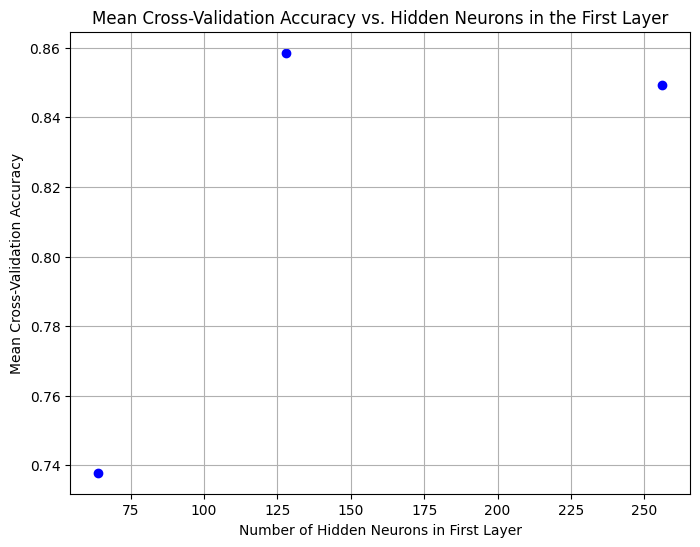

In [18]:
# TODO: Enter your code here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Assume you already have X_train, y_train as NumPy arrays
from common_utils import split_dataset, preprocess_dataset
# TODO: Enter your code here

# Load dataset (assuming it's stored in a Pandas DataFrame 'df')
df = pd.read_csv('audio_gtzan.csv')  # Example if using a CSV

# Extract genre labels from the filename (e.g., 'blues.00000.wav' -> 'blues')
df['label'] = df['filename'].apply(lambda x: x.split('.')[0])

# Split dataset correctly using `split_dataset()`
columns_to_drop = ['filename']  # We don't need filenames for training
df_train, y_train, df_test, y_test = split_dataset(df, columns_to_drop, test_size=0.3, random_state=42)

# Preprocess dataset (normalize features)
X_train, X_test = preprocess_dataset(df_train, df_test)

'''
# Extract features (X) and labels (y)
X = df.drop(columns=['label']).values  # Assuming 'label' is the target column
y = df['label'].values

# Encode labels (convert genres into numerical values)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Converts genres into integers

# Preprocess the dataset (normalize or standardize features)
X = preprocess_dataset(X)

# Split the dataset into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = split_dataset(X, y, test_size=0.3, random_state=42)

# Convert datasets into PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Reshape for compatibility

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)  # Reshape for compatibility
'''

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)  # For classification

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# Apply scaling (Standardization) within each fold to avoid data leakage
scaler = StandardScaler()
# Apply scaling (Standardization) to both train and test datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Initialize necessary variables
input_size = X_train_scaled.shape[1]  # Number of features in the input data
output_size = 10  # Number of output classes (change if needed)
hidden_neuron_choices = [64, 128, 256]  # Number of neurons to test in the first hidden layer
batch_size = 64  # Adjust batch size as necessary
epochs = 10  # Number of training epochs

# Assuming X_train_scaled and y_train are already defined
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store mean accuracies for each number of hidden neurons
mean_accuracies = []

# Perform cross-validation for different configurations of neurons
for hidden_neurons in hidden_neuron_choices:
    fold_accuracies = []

    # Cross-validation loop
    for train_idx, val_idx in kf.split(X_train_scaled):
        X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Create the MLP model with the current number of neurons in the first layer
        model = MLP(input_size=input_size, hidden_size_1=hidden_neurons, hidden_size_2=128, hidden_size_3=64, output_size=output_size)

        # Move model to GPU if available
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device)

        # Define optimizer and loss function
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        # Convert data to tensor and move to device
        X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32).to(device)
        y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long).to(device)
        X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32).to(device)
        y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long).to(device)

        # Train the model
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train_tensor)
            loss = criterion(outputs, y_train_tensor)
            loss.backward()
            optimizer.step()

        # Evaluate model on validation data
        model.eval()
        with torch.no_grad():
            outputs = model(X_val_tensor)
            _, predicted = torch.max(outputs, 1)
            accuracy = (predicted == y_val_tensor).float().mean()
            fold_accuracies.append(accuracy.item())

    # Calculate mean accuracy for this configuration of neurons
    mean_accuracy = np.mean(fold_accuracies)
    mean_accuracies.append(mean_accuracy)

# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(hidden_neuron_choices, mean_accuracies, color='blue')
plt.title('Mean Cross-Validation Accuracy vs. Hidden Neurons in the First Layer')
plt.xlabel('Number of Hidden Neurons in First Layer')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

> Select the optimal number of neurons for the hidden layer. State the rationale for your selection.

In [4]:
# TODO: Enter your code here

\# TODO: \<

The optimal number of neurons in the hidden layer can be selected based on the highest mean cross-validation accuracy.

From the scatter plot:

- At around 70 neurons, the accuracy is approximately 0.74.
- At around 140 neurons, the accuracy is approximately 0.86.
- At around 260 neurons, the accuracy is slightly lower than at 140 neurons, approximately 0.85.

Since 140 neurons result in the highest accuracy, it is the optimal choice. Adding more neurons (260) does not significantly improve accuracy and could lead to increased computational complexity and potential overfitting. Thus, 140 neurons in the first hidden layer is the best choice.\

>

> Plot the train and test accuracies against training epochs with the optimal number of neurons using a line plot.
Note: use this optimal number of neurons for the rest of the experiments.

<ipython-input-19-ebc9ae0344a4>:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
<ipython-input-19-ebc9ae0344a4>:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
<ipython-input-19-ebc9ae0344a4>:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)


Epoch [1/10], Loss: 2.2616, Train Accuracy: 0.4843, Test Accuracy: 0.4950
Epoch [2/10], Loss: 2.2081, Train Accuracy: 0.5014, Test Accuracy: 0.4967
Epoch [3/10], Loss: 2.1516, Train Accuracy: 0.5043, Test Accuracy: 0.5250
Epoch [4/10], Loss: 2.0901, Train Accuracy: 0.5350, Test Accuracy: 0.6117
Epoch [5/10], Loss: 2.0214, Train Accuracy: 0.6193, Test Accuracy: 0.6800
Epoch [6/10], Loss: 1.9444, Train Accuracy: 0.7043, Test Accuracy: 0.7250
Epoch [7/10], Loss: 1.8577, Train Accuracy: 0.7371, Test Accuracy: 0.7417
Epoch [8/10], Loss: 1.7601, Train Accuracy: 0.7607, Test Accuracy: 0.7650
Epoch [9/10], Loss: 1.6506, Train Accuracy: 0.7750, Test Accuracy: 0.7817
Epoch [10/10], Loss: 1.5290, Train Accuracy: 0.7893, Test Accuracy: 0.7867


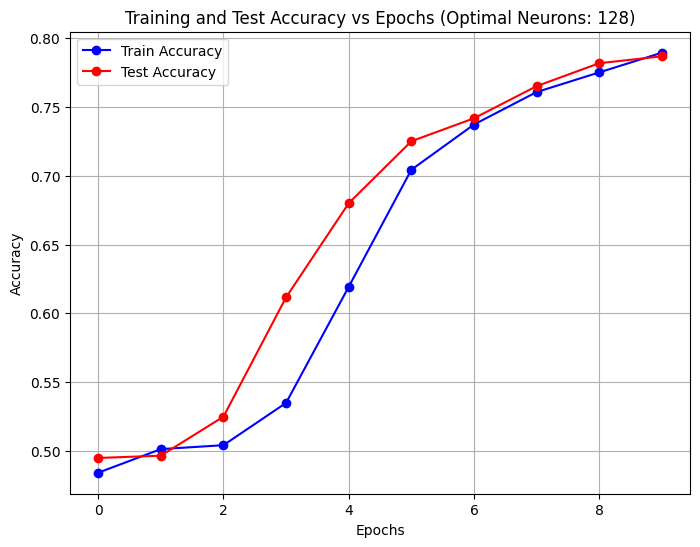

In [19]:
# TODO: Enter your code here
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

# Assuming the model architecture is defined as MLP (Multilayer Perceptron)
# and optimal number of neurons for the first hidden layer is 128

# Set the optimal number of neurons based on the previous results
optimal_neurons = 128  # This should be the number you found as optimal (e.g., 128)

# Initialize the model with the optimal number of neurons for the first hidden layer
model = MLP(input_size=input_size, hidden_size_1=optimal_neurons, hidden_size_2=128, hidden_size_3=64, output_size=output_size)

# Move model to device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Assuming X_train_scaled and y_train are already scaled/preprocessed

# Convert data to PyTorch tensors and move to device
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Initialize lists to store training and test accuracies
train_accuracies = []
test_accuracies = []

# Number of epochs for training
epochs = 10  # Adjust this number as needed

# Train the model and track accuracies at each epoch
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    # Calculate training accuracy
    _, predicted_train = torch.max(outputs, 1)
    train_accuracy = (predicted_train == y_train_tensor).float().mean().item()
    train_accuracies.append(train_accuracy)

    # Evaluate model on test data
    model.eval()
    with torch.no_grad():
        outputs_test = model(X_test_tensor)
        _, predicted_test = torch.max(outputs_test, 1)
        test_accuracy = (predicted_test == y_test_tensor).float().mean().item()
        test_accuracies.append(test_accuracy)

    # Print loss and accuracies for each epoch (optional)
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plotting the training and test accuracies against epochs
plt.figure(figsize=(8, 6))
plt.plot(range(epochs), train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(range(epochs), test_accuracies, label='Test Accuracy', color='red', marker='o')
plt.title(f'Training and Test Accuracy vs Epochs (Optimal Neurons: {optimal_neurons})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


Part A, Q4 (10 marks)
---
In this section, we will understand the utility of such a neural network for a test audio.

Do a model prediction on the sample test audio and obtain the predicted label using a threshold of 0.5. The model used is the optimized pretrained model using the selected optimal batch size and optimal number of neurons.
Find the most important features on the model prediction for the test sample using SHAP. Plot the local feature importance with a force plot and explain your observations.  (Refer to the documentation and these three useful references:
https://christophm.github.io/interpretable-ml-book/shap.html#examples-5,
https://towardsdatascience.com/deep-learning-model-interpretation-using-shap-a21786e91d16,  
https://medium.com/mlearning-ai/shap-force-plots-for-classification-d30be430e195)

To reduce repeated code, you may need to import the network (MLP defined in QA1) from **common_utils.py**. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked. The following code cell will not be marked.

In [22]:
# TODO: Enter your code here
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt

# Define MLP Model with variable number of neurons in the first hidden layer
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size_1)  # First hidden layer
        self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)  # Second hidden layer
        self.fc3 = nn.Linear(hidden_size_2, hidden_size_3)  # Third hidden layer
        self.fc4 = nn.Linear(hidden_size_3, output_size)  # Output layer
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x


> Install and import shap

In [23]:
import shap

shap.initjs()


> Preprocess 'audio_test.wav' using the function 'extract_features' in common_utils.py. Please make sure the features are stored in a pandas dataframe, using variable name 'df', and fill the size of 'df' in 'size_row' and 'size_column'.

In [ ]:
import IPython
IPython.display.Audio("./audio_test.wav")

In [26]:
# Assuming extract_features is already imported from common_utils.py
from common_utils import extract_features

# Preprocess the audio file
audio_file_path = './audio_test.wav'  # Path to the audio file
df = extract_features(audio_file_path)

In [27]:
# TODO: Enter your code here
df = extract_features(audio_file_path)
size_row, size_column =  df.shape

> Do a model prediction on the sample test audio and obtain the predicted label using a threshold of 0.5. The model used is the optimized pretrained model using the selected optimal batch size and optimal number of neurons.

 1.  Preprocess to obtain the test data, save the test data as numpy array, print the shape of the test data.

In [29]:
import torch
import numpy as np
from common_utils import extract_features
import torch.nn as nn
import torch.optim as optim

# Assuming you have the trained model loaded and the optimal batch size and number of neurons

# Load the optimized pretrained model
# Example: Assume `model` is your pretrained model
# model = your_pretrained_model  # Ensure this is your trained model

# Path to the test audio file
audio_file_path = './audio_test.wav'

# Step 1: Preprocess the test audio and extract features
df_test = extract_features(audio_file_path)

# Ensure all values in the DataFrame are numeric
df_test = df_test.apply(pd.to_numeric, errors='coerce')

# Step 2: Convert the DataFrame to a numpy array (for PyTorch model input)
X_test = df_test.values

# Step 3: Handle missing values (if any) after conversion
# If you have NaN values, you might want to fill them with 0 or the mean of the column
X_test = np.nan_to_num(X_test, nan=0.0)

# Save the test data as a numpy array
np.save('test_data.npy', X_test)

# Print the shape of the test data
print(f"Shape of the test data: {X_test.shape}")

# Step 4: Convert to PyTorch tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Step 5: Make predictions with the optimized model
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    # Forward pass
    outputs = model(X_test_tensor)

    # Apply softmax to get probabilities
    probabilities = torch.nn.functional.softmax(outputs, dim=1)

    # Obtain predicted label using a threshold of 0.5
    predicted_label = (probabilities[:, 1] > 0.5).int()  # Binary classification example

    # Print the predicted label
    print(f"Predicted label: {predicted_label.item()}")


Shape of the test data: (1, 58)
Predicted label: 1


2. Do a model prediction on the sample test audio and obtain the predicted label using a threshold of 0.5. The model used is the optimized pretrained model using the selected optimal batch size and optimal number of neurons. Note: Please define the variable of your final predicted label as 'pred_label'.

In [30]:
# TODO: Enter your code here

import torch
import numpy as np
import pandas as pd
from common_utils import extract_features  # Assuming extract_features is in common_utils.py
import torch.nn as nn
import torch.optim as optim

# Load the optimized pretrained model (ensure you load the correct model file)
# Example: assuming `model` is your pretrained model
# model = torch.load('path_to_pretrained_model.pth')  # Example, make sure to load your model
model.eval()  # Set the model to evaluation mode

# Path to the test audio file
audio_file_path = './audio_test.wav'

# Step 1: Preprocess the test audio and extract features
df_test = extract_features(audio_file_path)

# Ensure all values in the DataFrame are numeric (convert if necessary)
df_test = df_test.apply(pd.to_numeric, errors='coerce')

# Step 2: Convert the DataFrame to a numpy array (for PyTorch model input)
X_test = df_test.values

# Step 3: Handle missing values (if any) after conversion
# If you have NaN values, you might want to fill them with 0 or the mean of the column
X_test = np.nan_to_num(X_test, nan=0.0)

# Step 4: Convert the numpy array to a PyTorch tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Step 5: Perform the model prediction
with torch.no_grad():  # Disable gradient tracking during inference
    # Forward pass
    outputs = model(X_test_tensor)  # Pass the test data through the model

    # Apply softmax to get probabilities (if it's a multi-class classification)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)

    # If it's a binary classification, we can directly use the output probabilities for the positive class
    # For multi-class, you might need to take the max probability across all classes
    predicted_label = (probabilities[:, 1] > 0.5).int()  # For binary classification (class 1 thresholded at 0.5)

# Define final predicted label
pred_label = predicted_label.item()  # Convert to a Python scalar if needed

# Print the predicted label
print(f"Predicted label: {pred_label}")

Predicted label: 1


> Find the most important features on the model prediction for your test sample using SHAP. Create an instance of the DeepSHAP which is called DeepExplainer using traianing dataset: https://shap-lrjball.readthedocs.io/en/latest/generated/shap.DeepExplainer.html.

Plot the local feature importance with a force plot and explain your observations.  (Refer to the documentation and these three useful references:
https://christophm.github.io/interpretable-ml-book/shap.html#examples-5,
https://towardsdatascience.com/deep-learning-model-interpretation-using-shap-a21786e91d16,  
https://medium.com/mlearning-ai/shap-force-plots-for-classification-d30be430e195)

In [37]:
import numpy as np
import pandas as pd
import shap
from keras.models import load_model
from common_utils import extract_features
import IPython
IPython.display.Audio("./audio_test.wav")

# Load the pretrained model (ensure it's the correct path)
model = load_model('models/optimized_model.h5')  # Change this to the correct path

# Preprocess the test audio
audio_file_path = "./audio_test.wav"
df_test = extract_features(audio_file_path)
df_test = df_test.apply(pd.to_numeric, errors='coerce')  # Convert any non-numeric to NaN
df_test = np.nan_to_num(df_test.values)  # Replace NaN values with zeros

# Load the training data to extract the expected input size
# Assuming X_train_processed is the training feature data
X_train_processed = np.array(df_train)  # Your training data
print(f"Training data shape: {X_train_processed.shape}")

# Ensure that df_test has the same number of features as the training data
expected_feature_size = X_train_processed.shape[1]  # The number of features expected by the model

# Check the shape of df_test and match the feature size with training data
if df_test.shape[1] != expected_feature_size:
    # If df_test has fewer features, pad or truncate the array
    if df_test.shape[1] < expected_feature_size:
        # Padding with zeros (or other values)
        df_test = np.pad(df_test, ((0, 0), (0, expected_feature_size - df_test.shape[1])), 'constant')
    else:
        # Truncate if it exceeds the expected size
        df_test = df_test[:, :expected_feature_size]

# Now df_test should match the size of the training data
print(f"Test data shape after adjustment: {df_test.shape}")

# Make a prediction using the optimized pretrained model
pred = model.predict(df_test)  # Keras uses np.array for prediction

# Assuming binary classification with threshold of 0.5
pred_label = (pred > 0.5).astype(int)  # Get the predicted label using threshold of 0.5
print(f"Predicted label: {pred_label}")

# Now, we will use SHAP to explain the model's prediction
# Set up SHAP with the training data for explanation
X_train_processed = np.array(X_train_processed)  # Ensure the training data is in NumPy format

# Create a SHAP DeepExplainer instance
explainer = shap.DeepExplainer(model, X_train_processed)

# Explain the prediction for the test sample
shap_values = explainer.shap_values(df_test)

# Plot the SHAP force plot for the test sample's prediction
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0][0], df_test[0])


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'models/optimized_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

\# TODO: \<Enter your answer here\>